In [1]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
)

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    BaggingRegressor, AdaBoostRegressor
)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, confusion_matrix, classification_report, 
    roc_curve, auc, roc_auc_score, silhouette_score
)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
from patsy import (
    dmatrix, bs
)

# GAMs

Up until now, we’ve been obsessed with `Age`. But as you saw in your initial data preview, the Wage dataset has other variables like `Year` and `Education`. 

Generalized Additive Models (GAMs) are the solution to the question: *"How do I use all these flexible curves (splines, local regression) for multiple variables at the same time?"*

In [2]:
# Load the dataset
wage_df = pd.read_csv('Wage.csv')

# 1. Check data types and missing values
display(wage_df.info())

# 2. Preview the first few rows
display(wage_df.head())

# Set up global plotting parameters for academic clarity
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        3000 non-null   int64  
 1   age         3000 non-null   int64  
 2   maritl      3000 non-null   object 
 3   race        3000 non-null   object 
 4   education   3000 non-null   object 
 5   region      3000 non-null   object 
 6   jobclass    3000 non-null   object 
 7   health      3000 non-null   object 
 8   health_ins  3000 non-null   object 
 9   logwage     3000 non-null   float64
 10  wage        3000 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 257.9+ KB


None

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


## Local Regression (LOWESS)

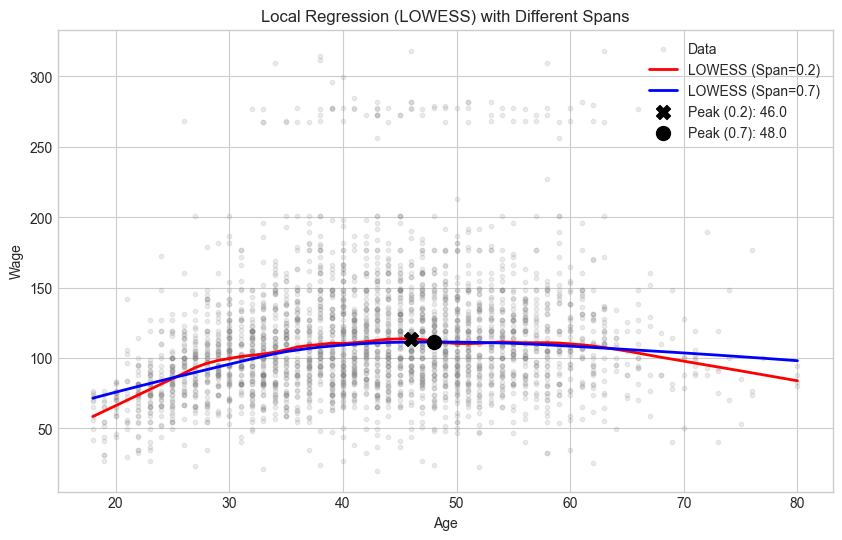

Peak Age with 20% Span: 46.0
Peak Age with 70% Span: 48.0


In [4]:
# -----------------------------
# 1. Compute LOWESS
# -----------------------------
# lowess returns a 2D array: [:, 0] is the sorted x, [:, 1] is the smoothed y
# 'frac' is the span (percentage of data used for each local window)

# Small Span (0.2) - More "wiggly", follows local data closely
lowess_02 = lowess(wage_df['wage'], wage_df['age'], frac=0.2)

# Large Span (0.7) - Smoother, captures the broad global trend
lowess_07 = lowess(wage_df['wage'], wage_df['age'], frac=0.7)

# -----------------------------
# 2. Extract Peaks
# -----------------------------
# Since LOWESS gives us points, we find the index of the maximum y-value
idx_02 = np.argmax(lowess_02[:, 1])
peak_age_02 = lowess_02[idx_02, 0]
peak_wage_02 = lowess_02[idx_02, 1]

idx_07 = np.argmax(lowess_07[:, 1])
peak_age_07 = lowess_07[idx_07, 0]
peak_wage_07 = lowess_07[idx_07, 1]

# -----------------------------
# 3. Plotting
# -----------------------------
plt.figure(figsize=(10, 6))
plt.scatter(wage_df['age'], wage_df['wage'], alpha=0.15, color='gray', s=10, label='Data')

plt.plot(lowess_02[:, 0], lowess_02[:, 1], color='red', lw=2, label='LOWESS (Span=0.2)')
plt.plot(lowess_07[:, 0], lowess_07[:, 1], color='blue', lw=2, label='LOWESS (Span=0.7)')

# Mark the peaks
plt.scatter(peak_age_02, peak_wage_02, color='black', marker='X', s=100, zorder=5, label=f'Peak (0.2): {peak_age_02:.1f}')
plt.scatter(peak_age_07, peak_wage_07, color='black', marker='o', s=100, zorder=5, label=f'Peak (0.7): {peak_age_07:.1f}')

plt.title("Local Regression (LOWESS) with Different Spans")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.legend()
plt.show()

print(f"Peak Age with 20% Span: {peak_age_02}")
print(f"Peak Age with 70% Span: {peak_age_07}")

Unlike Splines or Polynomials, **Local Regression** does not fit a single global equation to the data. Instead, it computes the fit at a target point $x_0$ using only the "nearby" observations. 

### How it Works:
1. **The Window:** For a target age (e.g., 40), the model selects a "span" of the nearest data points (e.g., everyone aged 35 to 45).
2. **The Weighting:** It applies a **Kernel function** that gives the highest weight to people exactly aged 40 and decreasing weights to those further away.
3. **The Local Fit:** A weighted least squares regression is performed within that window.
4. **The Result:** This process is repeated for every point across the x-axis, creating a smooth, "sliding" fit.

### The Power of the Span ($s$):
The **Span** (or `frac` in Python) is the most critical tuning parameter:
* **Small Span ($s=0.2$):** The window is narrow. The model is highly flexible and can capture sudden shifts in the wage-age relationship, but it may become "choppy" by following random noise (High Variance).
* **Large Span ($s=0.7$):** The window is wide. The model averages out more data, resulting in a much smoother curve that ignores local fluctuations (High Bias).

### Practical Observation:
Notice how the **Peak Age** shifts depending on the span. Local regression is "memory-based"—it doesn't care about the boundary constraints that pull on Natural Splines. This makes it an excellent tool for exploratory analysis when you want to see exactly where the data "wants" to go without the influence of a global formula.

In our previous models (Polynomials and Splines), we used **Global or Piecewise Parametric** approaches. This means the model "distills" the data into a few fixed numbers (coefficients). **Local Regression (LOWESS)** operates under a completely different philosophy called **Memory-Based Learning**.

#### 1. No Stored Equation
When you fit an OLS or Spline model, you calculate values like $\beta_0, \beta_1, \dots$. Once those numbers are saved, you can delete the raw data and still predict the wage for a 45-year-old using a simple formula.

LOWESS does not have an equation. It is **non-parametric**. 
* The "model" *is* the data itself.
* To find a value at Age 45, the computer must look at the raw data "nearby" (within the span) and perform a new calculation on the fly.

#### 2. The Prediction Limitation
In Python's `statsmodels.nonparametric.lowess`, the function typically returns a smoothed version of the *existing* data points. It does not natively provide a `.predict()` method for new, unseen ages. 
* **To predict for Age 45.5:** You would have to use **Linear Interpolation**, essentially drawing a tiny straight line between the smoothed values of Age 45 and Age 46.
* This makes LOWESS computationally "expensive" for large datasets and less practical for production environments where fast predictions are needed.

- #### 3. Comparison: Parametric vs. Non-Parametric

| Feature | Splines / Polynomials (Parametric) | LOWESS (Non-Parametric) |
| :--- | :--- | :--- |
| **Model Storage** | Small (just the coefficients) | Large (requires all raw data) |
| **Flexibility** | Limited by degree/knots | Virtually unlimited (dictated by `frac`) |
| **Prediction** | Easy via mathematical formula | Difficult (requires interpolation) |
| **Best Use Case** | Deploying a finalized model | Exploratory Data Analysis (EDA) |

# Generalized Additive Models (GAMs)

GAMs allow us to bridge the gap between simple linear models and complex "black-box" machine learning. They provide a framework to fit non-linear functions to multiple predictors simultaneously.

### Key Features:
1. **Flexibility:** We can use a different "shape" for every variable. We can use a spline for Age, a linear trend for Year, and a set of constant shifts for Education.
2. **Additivity:** Because the functions are added together ($f_1 + f_2 + f_3$), we can hold other variables constant and see the "partial effect" of one specific variable. For example: *"How does age affect wage, assuming education level is the same?"*
3. **Interpretability:** You can plot each function individually. This allows you to explain to a stakeholder exactly how the model is making its decisions.

### The Trade-off:
The main limitation of a standard GAM is that it assumes **additivity**. It assumes the effect of Age doesn't change based on your Education level (no interactions). While you *can* add interaction terms ($f(Age, Education)$), it makes the model much more complex to visualize.

In [7]:
# We use cr() for a Natural Spline on Age
# We use C() to treat Education as a Categorical variable
try_model = smf.ols("wage ~ cr(age, df=5)", data=wage_df).fit()

display(try_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     71.54
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           5.90e-58
Time:                        16:37:18   Log-Likelihood:                -15313.
No. Observations:                3000   AIC:                         3.064e+04
Df Residuals:                    2995   BIC:                         3.067e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           80.7444      2.033     39.708      0.000      76.757      84.732
cr(age, df=5)[0]   -23.1033      3.691     -6.259      0.000     -30.341     -15.866
cr(age, df=5)[1]    29.9115      2.545     11.751      0.000      24.921      34.902
cr(age, df=5)[2]    37.6694      2.148     17.538      0.000      33.458      41.881
cr(age, df=5)[3]    35.1290      2.792     12.582      0.000      29.654      40.604
cr(age, df=5)[4]     1.1378      9.043      0.126      0.900     -16.594      18.870
==============================================================================
Omnibus:                     1092.706   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4916.713
Skew:                           1.715   Prob(JB):                         0.00
Kurtosis:                       8.251   Cond. No.                     2.56e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 6.23e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [6]:
# We use cr() for a Natural Spline on Age
# We use C() to treat Education as a Categorical variable
gam_model = smf.ols("wage ~ cr(age, df=5) + year + C(education)", data=wage_df).fit()

display(gam_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     136.6
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          3.70e-216
Time:                        16:27:21   Log-Likelihood:                -14933.
No. Observations:                3000   AIC:                         2.989e+04
Df Residuals:                    2990   BIC:                         2.995e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
======================================================================================================
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                          -1888.5718    531.086     -3.556      0.000   -2929.902    -847.241
C(education)[T.2. HS Grad]            10.8723      2.429      4.476      0.000       6.110      15.635
C(education)[T.3. Some College]       23.3144      2.557      9.117      0.000      18.300      28.328
C(education)[T.4. College Grad]       37.9215      2.542     14.921      0.000      32.938      42.905
C(education)[T.5. Advanced Degree]    62.3684      2.761     22.590      0.000      56.955      67.782
cr(age, df=5)[0]                    -407.1596    106.293     -3.831      0.000    -615.574    -198.745
cr(age, df=5)[1]                    -369.4505    106.216     -3.478      0.001    -577.714    -161.187
cr(age, df=5)[2]                    -360.6329    106.227     -3.395      0.001    -568.919    -152.347
cr(age, df=5)[3]                    -365.7754    106.339     -3.440      0.001    -574.280    -157.271
cr(age, df=5)[4]                    -385.5534    106.428     -3.623      0.000    -594.233    -176.873
year                                   1.1674      0.318      3.674      0.000       0.544       1.790
==============================================================================
Omnibus:                     1038.228   Durbin-Watson:                   1.977
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5565.212
Skew:                           1.553   Prob(JB):                         0.00
Kurtosis:                       8.905   Cond. No.                     8.99e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.5e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

### Interpreting the Multi-Variable GAM Results

Our Generalized Additive Model ($R^2 = 0.291$) allows us to isolate the impact of different life factors on earnings.

#### Key Takeaways:
1. **The Education Gap:** Education is the strongest predictor in the model. An **Advanced Degree** provides a massive **$62,368$ premium** over someone who did not finish high school, even when comparing people of the same age.
2. **The "Year" Raise:** There is a statistically significant "time effect." For every year that passes, the average wage in this population shifts upward by approximately **$1,167$**.
3. **The Non-Linear Age Effect:** Even when we control for education (e.g., comparing a College Grad at 25 vs. a College Grad at 45), the **Age Spline** remains highly significant ($p < 0.001$). This confirms that "Experience" has a unique value that is separate from formal "Education."

#### Model Performance:
With an F-statistic of **136.6** and a near-zero probability, the model as a whole is highly significant. While we only explain 29% of the total variation, this is quite high for human-centric data (where individual luck, specific companies, and negotiation skills play a huge role).